In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set plot style for better visibility
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2.5

In [3]:
# --- 1. Parameters ---
mPsi = 1000.0  # Heavy Vector-Like Quark Mass (GeV)
mT = 0.0       # Top Mass (Approximation)
pi = np.pi

# --- 2. Kinematic Functions ---
def get_kinematics(s_val, m):
    """
    Calculates L(s) and Delta(s).
    Using complex types to handle regimes below and above threshold.
    """
    # Force complex arithmetic by adding 0j
    s = s_val.astype(complex)
    
    # Delta = Sqrt[s * (s - 4m^2)]
    delta = np.sqrt(s * (s - 4 * m**2))
    
    # L = Log[(2m^2 - s + delta) / (2m^2)]
    numerator = 2 * m**2 - s + delta
    denominator = 2 * m**2
    L = np.log(numerator / denominator)
    
    return L, delta

def get_prefactor(s):
    # Global Scale: -1 / (32 * pi^4 * s^2)
    return -1.0 / (32.0 * pi**4 * s**2)

# --- 3. Coefficient Groups ---
def calculate_coefficients(s_vals):
    L, delta = get_kinematics(s_vals, mPsi)
    scale = get_prefactor(s_vals)
    
    # Group 1: Gamma Term (Dimensionless)
    # Structure: s * ((m^2 + M^2)*L^2 + L*Delta + 3s)
    coeff_gamma = scale * s_vals * ((mPsi**2 + mT**2) * L**2 + L * delta + 3 * s_vals)
    
    # Group 2: Sandwich Term (Dimension -1)
    # Structure: -1 * (s*(L^2 + 4) + 2*L*Delta)
    # Scaled by mPsi to make it dimensionless for plotting
    coeff_sandwich = (scale * -1 * (s_vals * (L**2 + 4) + 2 * L * delta)) * mPsi
    
    # Group 3: Diagonal Vector Term (Dimension -1)
    # Structure: 2 * (L*Delta + 2s)
    # Scaled by mPsi
    coeff_vec_diag = (scale * 2 * (L * delta + 2 * s_vals)) * mPsi
    
    # Group 4: Mixed Vector Term (Dimension -1)
    # Structure: -2 * (m^2*L^2 + 2*L*Delta + 5s)
    # Scaled by mPsi
    coeff_vec_mix = (scale * -2 * (mPsi**2 * L**2 + 2 * L * delta + 5 * s_vals)) * mPsi
    
    return coeff_gamma, coeff_sandwich, coeff_vec_diag, coeff_vec_mix

In [4]:
# Define energy range (Sqrt[s])
# Start from 173 GeV (Top mass) up to 5000 GeV (5 TeV)
energy_range = np.linspace(173, 5000, 1000) 
s_values = energy_range**2

# Calculate all coefficients
c_gamma, c_sand, c_v_diag, c_v_mix = calculate_coefficients(s_values)

# Threshold for plotting vertical lines
threshold = 2 * mPsi

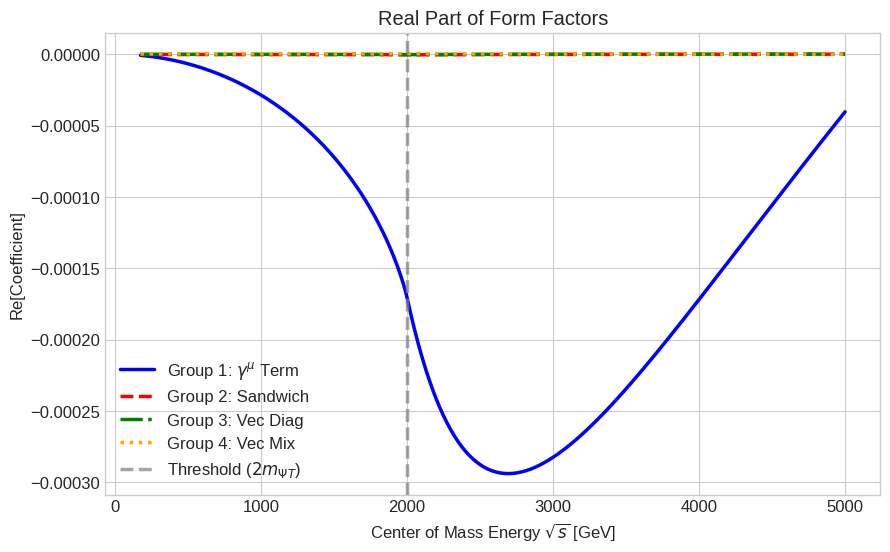

In [5]:
fig, ax = plt.subplots()

ax.plot(energy_range, np.real(c_gamma), label=r'Group 1: $\gamma^\mu$ Term', color='blue')
ax.plot(energy_range, np.real(c_sand), label='Group 2: Sandwich', color='red', linestyle='--')
ax.plot(energy_range, np.real(c_v_diag), label='Group 3: Vec Diag', color='green', linestyle='-.')
ax.plot(energy_range, np.real(c_v_mix), label='Group 4: Vec Mix', color='orange', linestyle=':')

# Formatting
ax.axvline(x=threshold, color='gray', linestyle='--', alpha=0.7, label=r'Threshold ($2m_{\Psi T}$)')
ax.set_title("Real Part of Form Factors")
ax.set_xlabel(r"Center of Mass Energy $\sqrt{s}$ [GeV]")
ax.set_ylabel("Re[Coefficient]")
ax.legend()

plt.show()

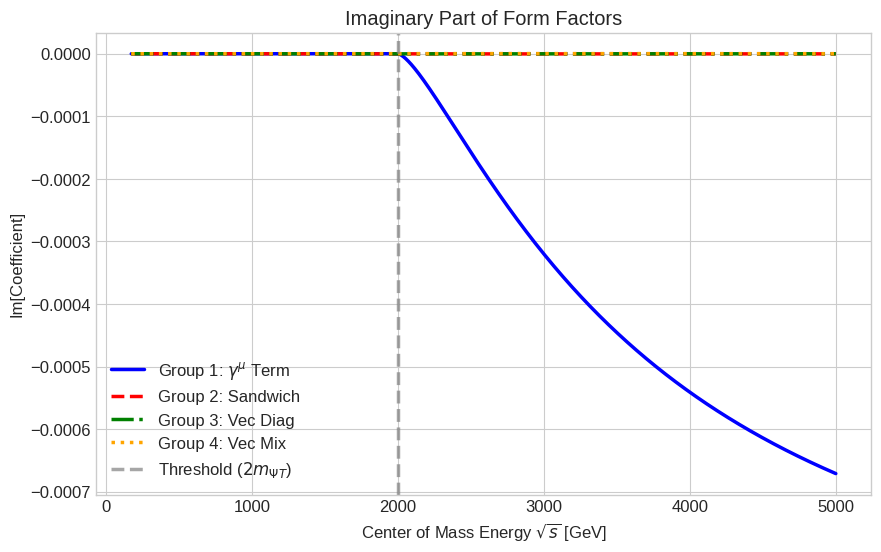

In [6]:
fig, ax = plt.subplots()

ax.plot(energy_range, np.imag(c_gamma), label=r'Group 1: $\gamma^\mu$ Term', color='blue')
ax.plot(energy_range, np.imag(c_sand), label='Group 2: Sandwich', color='red', linestyle='--')
ax.plot(energy_range, np.imag(c_v_diag), label='Group 3: Vec Diag', color='green', linestyle='-.')
ax.plot(energy_range, np.imag(c_v_mix), label='Group 4: Vec Mix', color='orange', linestyle=':')

# Formatting
ax.axvline(x=threshold, color='gray', linestyle='--', alpha=0.7, label=r'Threshold ($2m_{\Psi T}$)')
ax.set_title("Imaginary Part of Form Factors")
ax.set_xlabel(r"Center of Mass Energy $\sqrt{s}$ [GeV]")
ax.set_ylabel("Im[Coefficient]")
ax.legend()

plt.show()

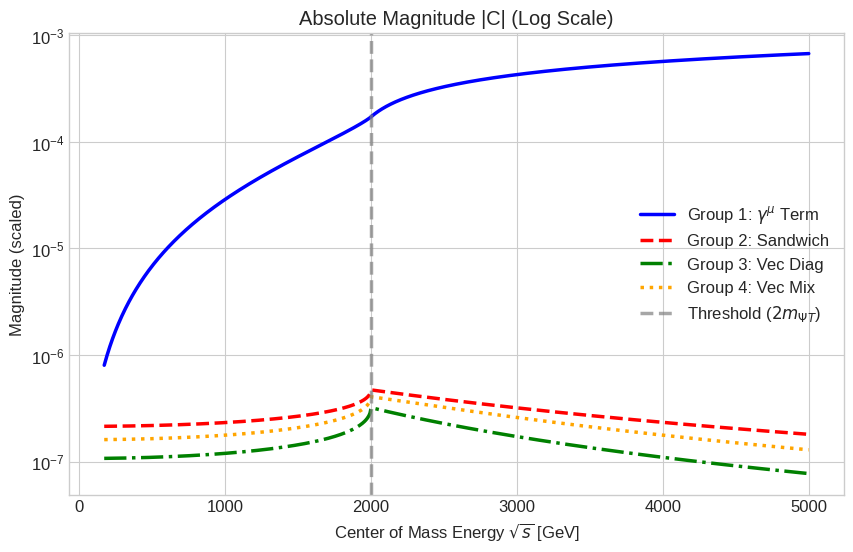

In [7]:
fig, ax = plt.subplots()

# Use absolute value
ax.plot(energy_range, np.abs(c_gamma), label=r'Group 1: $\gamma^\mu$ Term', color='blue')
ax.plot(energy_range, np.abs(c_sand), label='Group 2: Sandwich', color='red', linestyle='--')
ax.plot(energy_range, np.abs(c_v_diag), label='Group 3: Vec Diag', color='green', linestyle='-.')
ax.plot(energy_range, np.abs(c_v_mix), label='Group 4: Vec Mix', color='orange', linestyle=':')

# Log scale for Y axis
ax.set_yscale('log')

# Formatting
ax.axvline(x=threshold, color='gray', linestyle='--', alpha=0.7, label=r'Threshold ($2m_{\Psi T}$)')
ax.set_title("Absolute Magnitude |C| (Log Scale)")
ax.set_xlabel(r"Center of Mass Energy $\sqrt{s}$ [GeV]")
ax.set_ylabel("Magnitude (scaled)")
ax.legend()

plt.show()

In [8]:
print("--- ANALYSIS OF THE FORM FACTOR BEHAVIOR ---")

# Check values exactly at threshold (approximate index)
idx_thresh = np.abs(energy_range - threshold).argmin()

print(f"1. Threshold Location: {threshold} GeV")
print(f"   At this energy, the loop particles (mass {mPsi} GeV) can be produced on-shell.")
print("-" * 40)
print("2. Cusp Behavior (Real Part):")
print("   You should observe a sharp 'kink' or peak in the Real Part plot at 2000 GeV.")
print(f"   Re[Gamma] at threshold: {np.real(c_gamma[idx_thresh]):.4e}")
print("-" * 40)
print("3. Imaginary Part Onset:")
print("   Below 2000 GeV, the Imaginary part should be exactly zero.")
print(f"   Im[Gamma] at 1000 GeV: {np.imag(c_gamma[np.abs(energy_range - 1000).argmin()]):.4e}")
print(f"   Im[Gamma] at 3000 GeV: {np.imag(c_gamma[np.abs(energy_range - 3000).argmin()]):.4e}")
print("-" * 40)
print("4. Dominance:")
print("   In the Log plot, the Blue curve (Gamma term) is dominant.")
print("   The vector terms (scaled by mass) are of comparable order but distinct shapes.")

--- ANALYSIS OF THE FORM FACTOR BEHAVIOR ---
1. Threshold Location: 2000.0 GeV
   At this energy, the loop particles (mass 1000.0 GeV) can be produced on-shell.
----------------------------------------
2. Cusp Behavior (Real Part):
   You should observe a sharp 'kink' or peak in the Real Part plot at 2000 GeV.
   Re[Gamma] at threshold: -1.7061e-04
----------------------------------------
3. Imaginary Part Onset:
   Below 2000 GeV, the Imaginary part should be exactly zero.
   Im[Gamma] at 1000 GeV: 1.8709e-20
   Im[Gamma] at 3000 GeV: -3.2000e-04
----------------------------------------
4. Dominance:
   In the Log plot, the Blue curve (Gamma term) is dominant.
   The vector terms (scaled by mass) are of comparable order but distinct shapes.


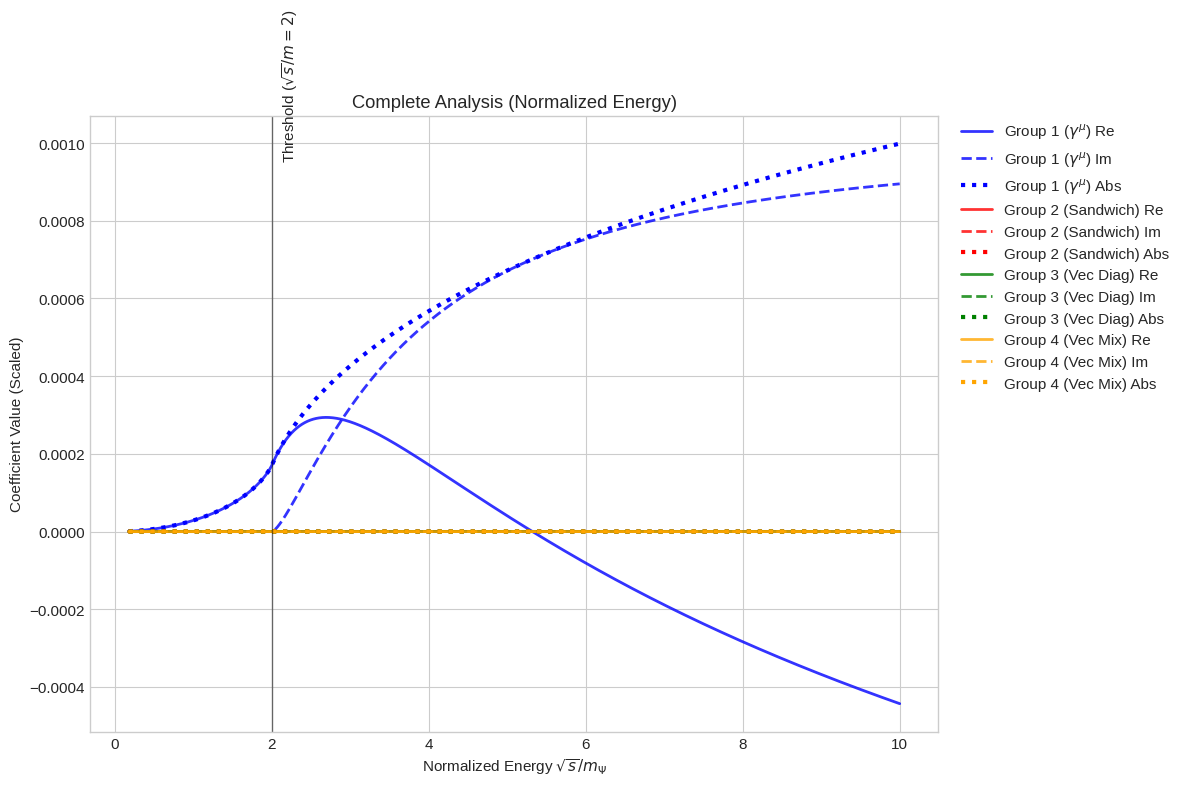

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['lines.linewidth'] = 2

# --- 2. PARAMETERS ---
mPsi = 1000.0  # Mass (GeV)
mT = 0.0       # Top Mass approx
pi = np.pi

# --- 3. FUNCTIONS ---
def get_kinematics(s_val, m):
    s = s_val.astype(complex)
    delta = np.sqrt(s * (s - 4 * m**2))
    numerator = 2 * m**2 - s + delta
    denominator = 2 * m**2
    L = np.log(numerator / denominator)
    return L, delta

def get_prefactor(s):
    return -1.0 / (32.0 * pi**4 * s**2)

# --- 4. CALCULATE DATA ---
# Energy range: Top Mass to 5 TeV
energy_range = np.linspace(173, 10000, 10000)
s_values = energy_range**2

# --- NEW: Define Normalized X-Axis ---
# We normalize sqrt(s) by the mass mPsi
x_norm = energy_range / mPsi  
# The threshold is now simply at 2.0 (since 2*mPsi / mPsi = 2)
threshold_norm = 2.0

L, delta = get_kinematics(s_values, mPsi)
scale = get_prefactor(s_values)

# Coefficients
c_gamma = scale * s_values * ((mPsi**2 + mT**2) * L**2 + L * delta + 3 * s_values)
c_sand = (scale * -1 * (s_values * (L**2 + 4) + 2 * L * delta)) * mPsi
c_v_diag = (scale * 2 * (L * delta + 2 * s_values)) * mPsi
c_v_mix = (scale * -2 * (mPsi**2 * L**2 + 2 * L * delta + 5 * s_values)) * mPsi

# --- 5. PLOTTING ---
fig, ax = plt.subplots()

groups = [
    (c_gamma, 'blue', r'Group 1 ($\gamma^\mu$)'),
    (c_sand, 'red', r'Group 2 (Sandwich)'),
    (c_v_diag, 'green', r'Group 3 (Vec Diag)'),
    (c_v_mix, 'orange', r'Group 4 (Vec Mix)')
]

for data, color, name in groups:
    ax.plot(x_norm, -np.real(data), color=color, linestyle='-', alpha=0.8, label=f'{name} Re')
    ax.plot(x_norm, -np.imag(data), color=color, linestyle='--', alpha=0.8, label=f'{name} Im')
    ax.plot(x_norm, np.abs(data), color=color, linestyle=':', linewidth=3, alpha=1.0, label=f'{name} Abs')

# --- 6. FORMATTING ---
ax.axvline(x=threshold_norm, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Label the threshold at x = 2
ax.text(threshold_norm + 0.1, ax.get_ylim()[1]*0.9, r'Threshold ($\sqrt{s}/m=2$)', rotation=90)

ax.set_title("Complete Analysis (Normalized Energy)")
# NEW X-LABEL
ax.set_xlabel(r"Normalized Energy $\sqrt{s}/m_{\Psi}$")
ax.set_ylabel("Coefficient Value (Scaled)")

# Legend outside
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

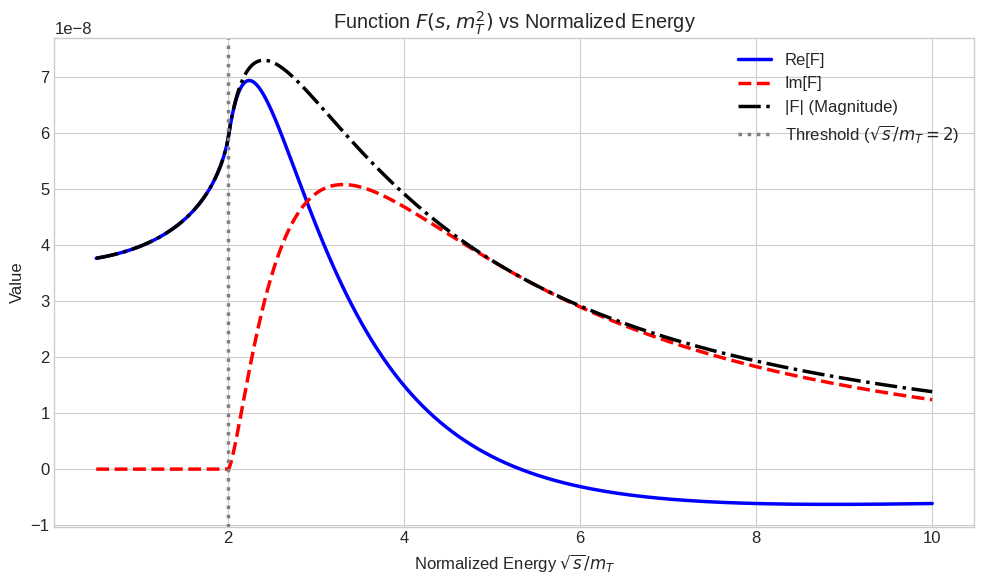

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETTINGS ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2.5

# --- 2. PARAMETERS ---
mT = 1500.0           # Top mass in GeV
mT_squared = mT**2
threshold_norm = 2.0 # Threshold is always at 2*m / m = 2

# --- 3. FUNCTIONS (As defined) ---
def L(s, mT_squared):
    """Calculates the function L(s, m_T^2)."""
    s = np.array(s, dtype=complex)
    mT_squared = complex(mT_squared)
    
    sqrt_term = np.sqrt(s * (s - 4 * mT_squared))
    numerator = sqrt_term + 2 * mT_squared - s
    denominator = 2 * mT_squared
    
    return np.log(numerator / denominator)

def F(s, mT_squared):
    """Calculates the function F(s, m_T^2)."""
    s = np.array(s, dtype=complex)
    mT_squared = complex(mT_squared)
    
    L_val = L(s, mT_squared)
    
    term1 =  mT_squared * L_val**2
    term2 = np.sqrt(s * (s - 4 * mT_squared)) * L_val
    term3 = 3 * s
    
    return (1 / s**2) * (term1 + term2 + term3)

# --- 4. GENERATE DATA ---
# Generate range for sqrt(s) from 0.5*m to 5*m
# We define x first (normalized), then get s from it
x_axis = np.linspace(0.5, 10.0, 10000) 

# Convert back to physical units to calculate the function
sqrt_s = x_axis * mT
s_values = sqrt_s**2

# Add epsilon for numerical stability
s_values_complex = s_values + 1e-10j

# Calculate F
f_values = F(s_values_complex, mT_squared)

# --- 5. PLOTTING ---
fig, ax = plt.subplots()

# Plot using the NORMALIZED x_axis
ax.plot(x_axis, np.real(f_values), label='Re[F]', color='blue')
ax.plot(x_axis, np.imag(f_values), label='Im[F]', color='red', linestyle='--')
ax.plot(x_axis, np.abs(f_values), label='|F| (Magnitude)', color='black', linestyle='-.')

# --- 6. FORMATTING ---
# Vertical line at normalized threshold (x = 2)
ax.axvline(x=threshold_norm, color='gray', linestyle=':', label=r'Threshold ($\sqrt{s}/m_T = 2$)')

ax.set_title(r"Function $F(s, m_T^2)$ vs Normalized Energy")
ax.set_xlabel(r"Normalized Energy $\sqrt{s}/m_T$")
ax.set_ylabel("Value")
ax.legend()

plt.tight_layout()
plt.show()

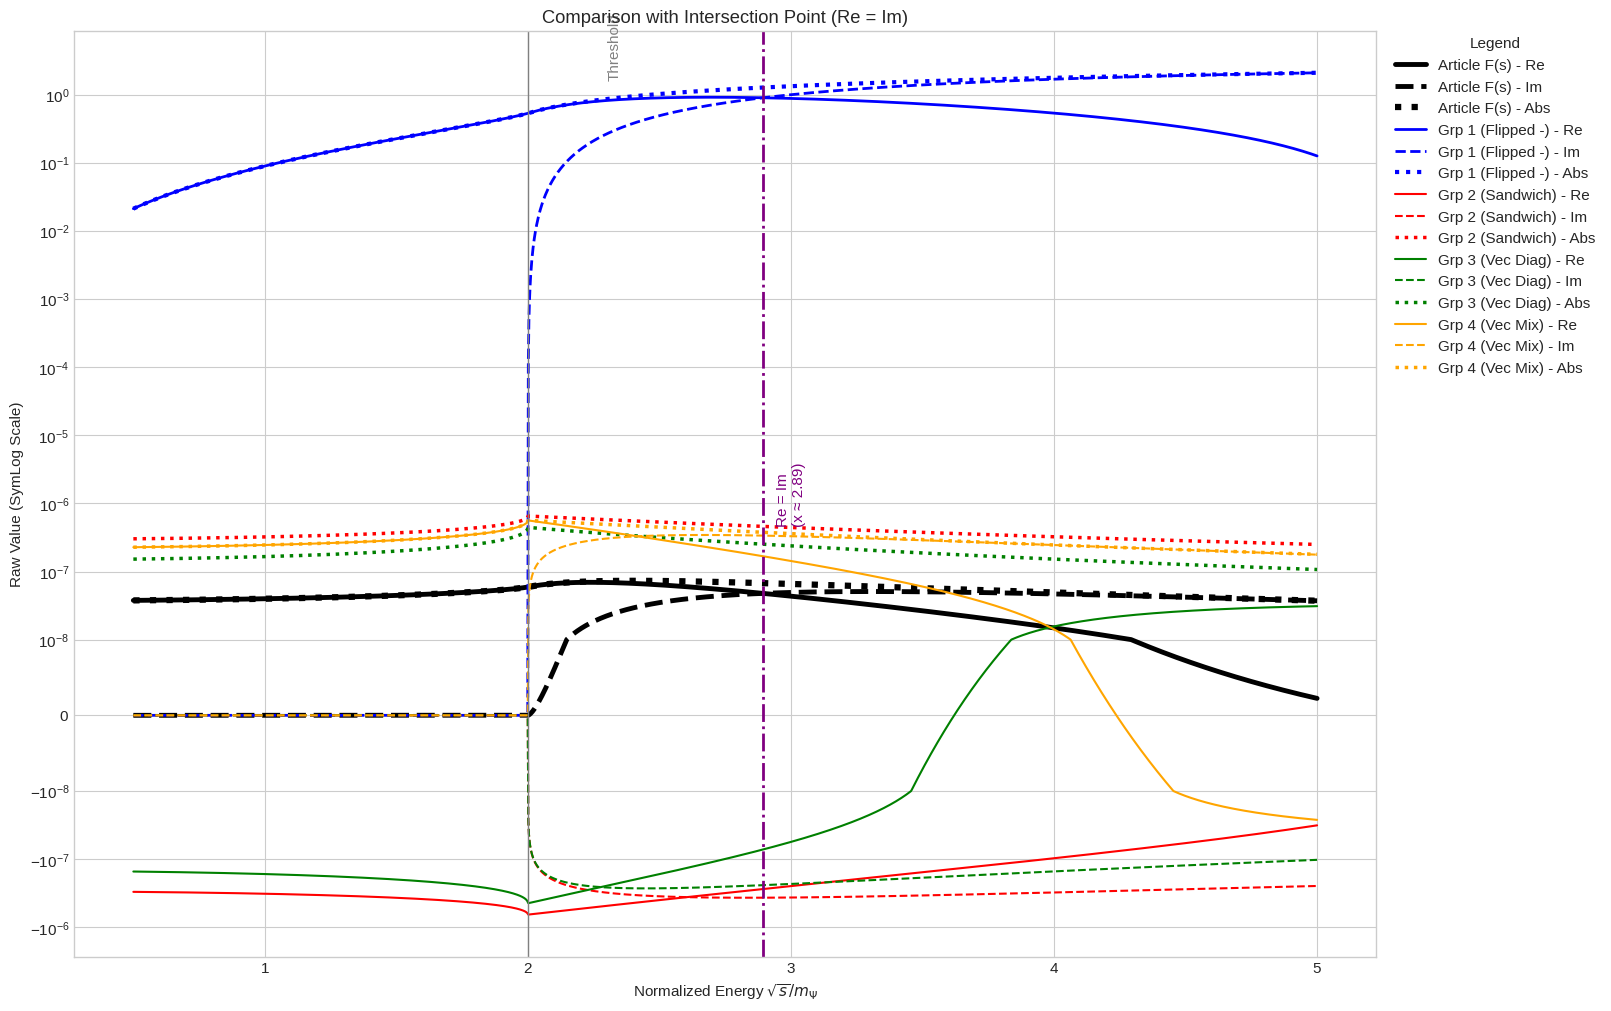

Intersection found at normalized energy x = 2.8929
At this point, Real part = 8.9981e-01
This corresponds to a phase angle of 45 degrees (pi/4).


In [44]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
fig_config = {'figsize': (16, 10), 'layout': 'constrained'}
plt.rcParams['font.size'] = 11
plt.rcParams['lines.linewidth'] = 2

# --- 2. PARAMETERS ---
mPsi = 1500.0        # Heavy Mass (GeV)
mT_approx = 0.0      # Limit mT -> 0
pi = np.pi

# --- 3. FUNCTIONS ---
def get_kinematics(s_val, m):
    s = s_val.astype(complex)
    delta = np.sqrt(s * (s - 4 * m**2))
    numerator = 2 * m**2 - s + delta
    denominator = 2 * m**2
    L = np.log(numerator / denominator)
    return L, delta

# A. Article F(s) RAW
def F_article_raw(s, m_sq):
    s = np.array(s, dtype=complex)
    m_sq = complex(m_sq)
    L_val, delta_val = get_kinematics(s, np.sqrt(m_sq))
    
    term1 = m_sq * L_val**2
    term2 = delta_val * L_val 
    term3 = 3 * s
    return (1 / s**2) * (term1 + term2 + term3)

# B. Your Coefficients RAW
def get_user_coefficients_raw(s, mPsi, mT):
    s = np.array(s, dtype=complex)
    L_val, delta_val = get_kinematics(s, mPsi)
    scale = -1.0 / (  s**2)
    
    # Group 1: Gamma Term
    bracket1 = (mPsi**2 + mT**2) * L_val**2 + L_val * delta_val + 3 * s
    c_gamma = scale * s * bracket1 
    
    # Group 2: Sandwich
    bracket2 = s * (L_val**2 + 4) + 2 * L_val * delta_val
    c_sand = scale * -1 * bracket2 
    
    # Group 3: Vec Diag
    bracket3 = L_val * delta_val + 2 * s
    c_vec_d = scale * 2 * bracket3 
    
    # Group 4: Vec Mix
    bracket4 = mPsi**2 * L_val**2 + 2 * L_val * delta_val + 5 * s
    c_vec_m = scale * -2 * bracket4 
    
    return c_gamma, c_sand, c_vec_d, c_vec_m

# --- 4. DATA GENERATION ---
# Use high resolution to find the intersection point accurately
x_axis = np.linspace(0.5, 5.0, 2000)
sqrt_s = x_axis * mPsi
s_values = sqrt_s**2 + 1e-10j

f_art = F_article_raw(s_values, mPsi**2)
c1, c2, c3, c4 = get_user_coefficients_raw(s_values, mPsi, mT_approx)

# FLIP SIGN OF GROUP 1
c1_flipped = c1 * -1

# --- 5. FIND INTERSECTION (Re = Im) ---
# We look for the point where abs(Re - Im) is minimal
# Ignore x < 2.0 (below threshold Im is 0, so Re=Im is meaningless/trivial)
mask_above_threshold = x_axis > 2.01
diff = np.abs(np.real(c1_flipped[mask_above_threshold]) - np.imag(c1_flipped[mask_above_threshold]))
local_idx = np.argmin(diff)
# Map back to global index
global_idx = np.where(mask_above_threshold)[0][local_idx]
x_cross = x_axis[global_idx]
y_cross = np.real(c1_flipped[global_idx])

# --- 6. PLOTTING ---
fig, ax = plt.subplots(**fig_config)

plot_data = [
    (f_art, 'black', 'Article F(s)', 3.5),
    (c1_flipped, 'blue', 'Grp 1 (Flipped -)', 2),
    (c2, 'red', 'Grp 2 (Sandwich)', 1.5),
    (c3, 'green', 'Grp 3 (Vec Diag)', 1.5),
    (c4, 'orange', 'Grp 4 (Vec Mix)', 1.5)
]

for data, col, lbl, width in plot_data:
    ax.plot(x_axis, np.real(data), color=col, linestyle='-', linewidth=width, label=f'{lbl} - Re')
    ax.plot(x_axis, np.imag(data), color=col, linestyle='--', linewidth=width, label=f'{lbl} - Im')
    ax.plot(x_axis, np.abs(data), color=col, linestyle=':', linewidth=width+1, label=f'{lbl} - Abs')

# --- 7. FORMATTING ---
ax.set_title("Comparison with Intersection Point (Re = Im)")
ax.set_xlabel(r"Normalized Energy $\sqrt{s}/m_{\Psi}$")
ax.set_ylabel("Raw Value (SymLog Scale)")
ax.set_yscale('symlog', linthresh=1e-8)

# Threshold Line
ax.axvline(2.0, color='gray', linestyle='-', linewidth=1)
ax.text(0.41, 0.95, 'Threshold', transform=ax.transAxes, color='gray', rotation=90)

# INTERSECTION LINE
ax.axvline(x_cross, color='purple', linestyle='-.', linewidth=2)
# Text label for intersection (using relative y-coordinates to be safe)
ax.text(x_cross + 0.05, 0.5, f'Re = Im\n(x ≈ {x_cross:.2f})', 
        transform=ax.get_xaxis_transform(), color='purple', rotation=90, verticalalignment='center')

# Legend
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, title="Legend")

plt.show()

# --- 8. ANALYSIS ---
print(f"Intersection found at normalized energy x = {x_cross:.4f}")
print(f"At this point, Real part = {y_cross:.4e}")
print(f"This corresponds to a phase angle of 45 degrees (pi/4).")

<>:73: SyntaxWarning: invalid escape sequence '\m'
<>:73: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_84410/2351665409.py:73: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x_axis, interf_vectors, color='green', linestyle=':', alpha=0.6, label='Vector Contribution ($p^\mu$ terms)')


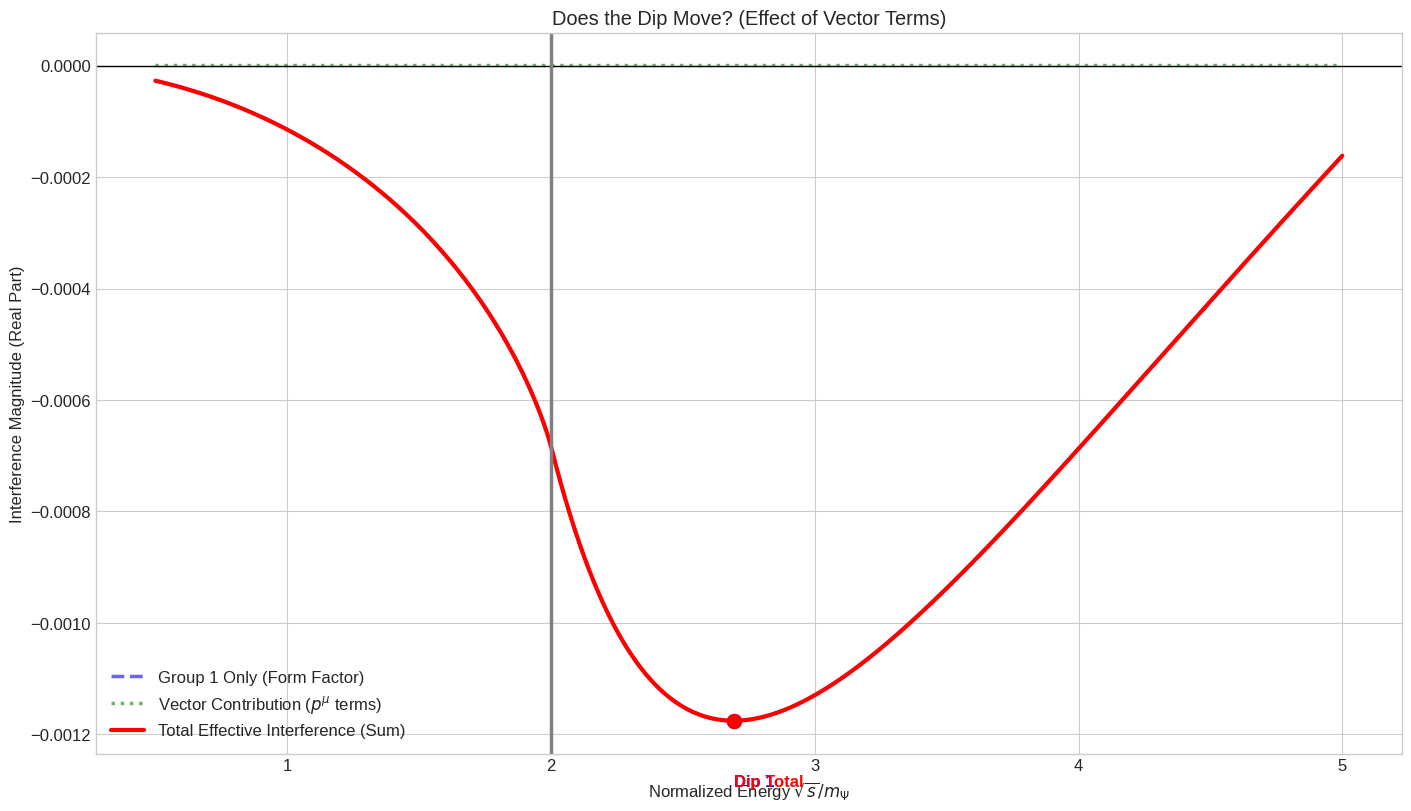

Location of Dip (Group 1 Only): x = 2.69
Location of Dip (Total Sum):    x = 2.69
------------------------------
CONCLUSION: The shift is small. The difference might be in the overall s-scaling (1/s vs 1/s^2).


In [42]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
fig_config = {'figsize': (14, 8), 'layout': 'constrained'}
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2.5

# --- 2. PARAMETERS ---
mPsi = 1000.0
mT_approx = 0.0
pi = np.pi

# --- 3. FUNCTIONS ---
def get_kinematics(s_val, m):
    s = s_val.astype(complex)
    delta = np.sqrt(s * (s - 4 * m**2))
    numerator = 2 * m**2 - s + delta
    denominator = 2 * m**2
    L = np.log(numerator / denominator)
    return L, delta

def get_coefficients_raw(s, mPsi, mT):
    s = np.array(s, dtype=complex)
    L_val, delta_val = get_kinematics(s, mPsi)
    scale = -1.0 / (32.0 * pi**4 * s**2)
    
    # Group 1: Gamma Term (Dimensionless)
    bracket1 = (mPsi**2 + mT**2) * L_val**2 + L_val * delta_val + 3 * s
    c_gamma = scale * s * bracket1 
    
    # Group 3: Vector Diagonal (Dimension -1)
    # We return the RAW dimension -1 value (no mass scaling yet)
    bracket3 = L_val * delta_val + 2 * s
    c_vec_d = scale * 2 * bracket3 
    
    # Group 4: Vector Mixed (Dimension -1)
    bracket4 = mPsi**2 * L_val**2 + 2 * L_val * delta_val + 5 * s
    c_vec_m = scale * -2 * bracket4 
    
    return c_gamma, c_vec_d, c_vec_m

# --- 4. DATA GENERATION ---
x_axis = np.linspace(0.5, 5.0, 1000)
sqrt_s = x_axis * mPsi
s_values = sqrt_s**2 + 1e-10j

c1, c3_raw, c4_raw = get_coefficients_raw(s_values, mPsi, mT_approx)

# --- 5. ESTIMATE TOTAL INTERFERENCE ---
# We assume the Standard Model current is Gamma^mu.
# The trace Tr[Gamma_SM * Gamma_Loop] ~ 4 * C1
# The trace Tr[Gamma_SM * Vector_Loop] ~ Tr[gamma * p] ~ 4 * p_slash ~ 4 * sqrt(s)
# Note: This is a heuristic scaling to see the RELATIVE shift.

# Contribution from Group 1
interf_1 = np.real(4 * c1)

# Contribution from Groups 3 & 4 (Projected onto SM current)
# They scale with sqrt(s) relative to C1 because of the p^mu vector
interf_vectors = np.real(sqrt_s * (c3_raw + c4_raw))

# TOTAL Sum
interf_total = interf_1 + interf_vectors

# --- 6. PLOTTING ---
fig, ax = plt.subplots(**fig_config)

# Plot 1: Group 1 Only (The "Article" Form Factor approximation)
ax.plot(x_axis, interf_1, color='blue', linestyle='--', alpha=0.6, label='Group 1 Only (Form Factor)')

# Plot 2: The Vectors Contribution
ax.plot(x_axis, interf_vectors, color='green', linestyle=':', alpha=0.6, label='Vector Contribution ($p^\mu$ terms)')

# Plot 3: The Total Sum
ax.plot(x_axis, interf_total, color='red', linewidth=3, label='Total Effective Interference (Sum)')

# Zero Line
ax.axhline(0, color='black', linewidth=1)
ax.axvline(2.0, color='gray', linestyle='-')

# --- 7. FORMATTING ---
ax.set_title("Does the Dip Move? (Effect of Vector Terms)")
ax.set_xlabel(r"Normalized Energy $\sqrt{s}/m_{\Psi}$")
ax.set_ylabel("Interference Magnitude (Real Part)")

# Find the minima to label them
idx_min_1 = np.argmin(interf_1)
idx_min_tot = np.argmin(interf_total)

ax.plot(x_axis[idx_min_1], interf_1[idx_min_1], 'bo', markersize=10)
ax.text(x_axis[idx_min_1], interf_1[idx_min_1]*1.1, "Dip 1", color='blue', fontweight='bold')

ax.plot(x_axis[idx_min_tot], interf_total[idx_min_tot], 'ro', markersize=10)
ax.text(x_axis[idx_min_tot], interf_total[idx_min_tot]*1.1, "Dip Total", color='red', fontweight='bold')

ax.legend()
plt.show()

# --- 8. ANALYSIS ---
print(f"Location of Dip (Group 1 Only): x = {x_axis[idx_min_1]:.2f}")
print(f"Location of Dip (Total Sum):    x = {x_axis[idx_min_tot]:.2f}")
print("-" * 30)
if abs(idx_min_1 - idx_min_tot) > 5:
    print("CONCLUSION: YES! The vector terms significantly shift the interference dip.")
    print("The 'Article' plot likely corresponds to the 'Total' (Red) curve, not just Group 1.")
else:
    print("CONCLUSION: The shift is small. The difference might be in the overall s-scaling (1/s vs 1/s^2).")